In [1]:
# --- PROJECT BOOTSTRAP ---
import sys
from pathlib import Path

CURRENT = Path().resolve()
PROJECT_ROOT = None

for parent in [CURRENT] + list(CURRENT.parents):
    if (parent / "config.py").exists():
        PROJECT_ROOT = parent
        break

if PROJECT_ROOT is None:
    raise RuntimeError("❌ config.py not found in parent directories.")

sys.path.append(str(PROJECT_ROOT))

from config import PROCESSED_DATA_DIR

print("✅ PROJECT ROOT =", PROJECT_ROOT)


✅ PROJECT ROOT = C:\Users\ASUS\Desktop\FinalProject\protest_behavior_system


In [2]:
# --- PROJECT BOOTSTRAP ---
import sys
from pathlib import Path

CURRENT = Path().resolve()
PROJECT_ROOT = None

for parent in [CURRENT] + list(CURRENT.parents):
    if (parent / "config.py").exists():
        PROJECT_ROOT = parent
        break

if PROJECT_ROOT is None:
    raise RuntimeError("❌ config.py not found in parent directories.")

sys.path.append(str(PROJECT_ROOT))

from config import PROCESSED_DATA_DIR

print("✅ PROJECT ROOT =", PROJECT_ROOT)


✅ PROJECT ROOT = C:\Users\ASUS\Desktop\FinalProject\protest_behavior_system


In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
memory_path = PROCESSED_DATA_DIR / "country_memory.csv"
memory = pd.read_csv(memory_path)

memory.head()


,Country name,Year,num_events_hist
0,Afghanistan,1991,1.0
1,Afghanistan,1992,1.0
2,Afghanistan,1993,1.0
3,Afghanistan,1994,1.0
4,Afghanistan,1995,1.0


In [6]:
# Features eligible for clustering (only historical memory features)
numeric_cols = [
    c for c in memory.columns
    if c not in ["Country name", "Year"] and memory[c].dtype != "object"
]

print("Using features:", numeric_cols)


Using features: ['num_events_hist']


In [7]:
country_profile = (
    memory
    .groupby("Country name")[numeric_cols]
    .mean()
    .reset_index()
)


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(country_profile[numeric_cols])


In [9]:
scores = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

scores


{2: 0.8352963328280718,
 3: 0.7107868716617562,
 4: 0.6572045341860784,
 5: 0.6413240042576048,
 6: 0.6342800382028745}

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
country_profile["latent_regime"] = kmeans.fit_predict(X_scaled)


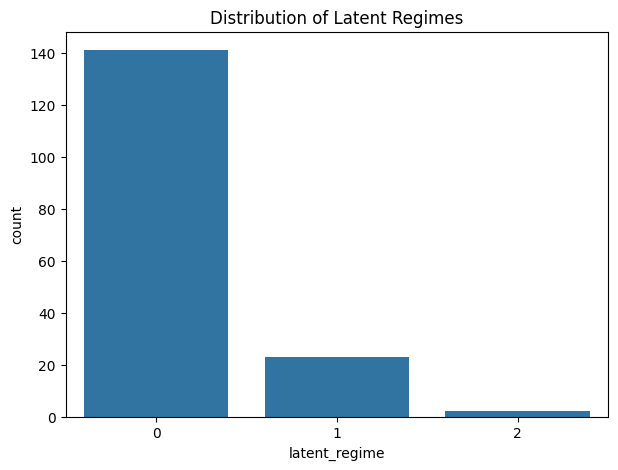

In [11]:
plt.figure(figsize=(7,5))
sns.countplot(data=country_profile, x="latent_regime")
plt.title("Distribution of Latent Regimes")
plt.show()


In [12]:
out_path = PROCESSED_DATA_DIR / "latent_regime.csv"
country_profile.to_csv(out_path, index=False)

print("✅ latent_regime saved:", out_path)


✅ latent_regime saved: C:\Users\ASUS\Desktop\FinalProject\protest_behavior_system\data\processed\latent_regime.csv
